# Two-Stage Market Dispatch in PyPSA-GB

This notebook explains how the PyPSA-GB two-stage market dispatch simulation works, walking through each stage with worked examples drawn from the `Historical_2020_ETYS_market` scenario.

---

## Background: How GB Electricity Markets Work

The GB electricity market operates in two distinct stages:

| Stage | Market | Boundary | What happens |
|-------|--------|----------|--------------|
| **1** | **Wholesale / Day-Ahead** | Gate closure (~1 hr ahead) | Generators submit bids/offers; a uniform clearing price is set assuming no network constraints ("copperplate") |
| **2** | **Balancing Mechanism (BM)** | Real-time | National Grid ESO (NESO) resolves network constraints by accepting bids (decrease) and offers (increase) from generators |

The key feature is the **separation of economics from physics**: the wholesale market sets the price, and the BM corrects for the physical reality of network congestion. Generators are paid **twice**:
- Their **wholesale revenue** (energy × wholesale price)
- **BM payments** for accepting NESO's instructions to deviate from their wholesale position

---

## PyPSA-GB Model Architecture

```
Network (.nc)
    │
    ├─── Stage 1: solve_wholesale.py
    │       • Relax all line/transformer s_nom → 1,000,000 MW  (copperplate)
    │       • Solve LP: minimise Σ marginal_cost · dispatch
    │       • Extract: wholesale dispatch, uniform price
    │
    └─── Stage 2: solve_balancing.py
            • Restore original s_nom (full network constraints)
            • Fix generators to wholesale positions via linopy constraints:
                  p = p_wholesale + increase − decrease
            • Objective: minimise Σ offer·increase + bid·decrease
            • Extract: BM redispatch volumes, nodal prices, congested lines
```

---

## Bid and Offer Prices

Because generators already have a wholesale contract, their BM prices represent the **marginal value of deviating**:

$$\text{offer price} = MC \times (1 + \text{offer markup})$$
$$\text{bid price} = \max\bigl(MC \times (1 - \text{bid discount}),\ 0.50\bigr)$$

Default markups (configurable per carrier in `defaults.yaml`):

| Carrier | Offer markup | Bid discount |
|---------|-------------|-------------|
| Default | +10% | −10% |
| Nuclear | +50% | −5% |
| Wind (onshore/offshore) | 0% | −5% |
| Battery | +15% | −15% |

Wind generators have zero offer markup because they have near-zero marginal cost — curtailment is essentially free in the BM.

THIS IS NOT REALLY TRUE AS RENEWABLES ARE SUBSIDISED AND WILL HAVE VERY DIFFERENT BIDS/OFFERS THAN EXPLORED HERE. NEXT STEP IS TO MAKE THIS PART MORE REALISTIC.

---

## Setup — Libraries and File Paths

The following cell loads standard libraries and resolves file paths to the `Historical_2020_ETYS_market` results under `resources/market/`. The path discovery logic walks up from the working directory to find the repository root, so this notebook runs correctly from any working directory.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
import os
from pathlib import Path
warnings.filterwarnings('ignore')

# ── Scenario ─────────────────────────────────────────────────────────
SCENARIO = 'Historical_2020_ETYS_market'

# ── File paths (relative from repo root) ────────────────────────────
PATHS = {
    'wholesale_dispatch':  f'resources/market/{SCENARIO}_wholesale_dispatch.csv',
    'wholesale_storage':   f'resources/market/{SCENARIO}_wholesale_storage.csv',
    'wholesale_links':     f'resources/market/{SCENARIO}_wholesale_links.csv',
    'wholesale_price':     f'resources/market/{SCENARIO}_wholesale_price.csv',
    'balancing_dispatch':  f'resources/market/{SCENARIO}_balancing_dispatch.csv',
    'redispatch':          f'resources/market/{SCENARIO}_redispatch_summary.csv',
    'costs':               f'resources/market/{SCENARIO}_constraint_costs.csv',
    'congestion':          f'resources/market/{SCENARIO}_congestion.csv',
    'price_cmp':           f'resources/market/{SCENARIO}_price_comparison.csv',
    'wholesale_network':   f'resources/market/{SCENARIO}_wholesale.nc',
    'balancing_network':   f'resources/market/{SCENARIO}_balancing.nc',
}

# ── Resolve absolute paths ────────────────────────────────────────────
cwd = Path(os.getcwd())
def _find_base(path):
    if (path / 'resources' / 'market').exists():
        return path
    for parent in path.parents:
        if (parent / 'resources' / 'market').exists():
            return parent
    return path
base = _find_base(cwd)
for k, v in list(PATHS.items()):
    p = Path(v)
    if not p.is_absolute():
        candidate = base / v
        PATHS[k] = str(candidate.resolve() if candidate.exists() else (cwd / v).resolve())

# ── Helper formatters ─────────────────────────────────────────────────
COLORS = {
    'wind_offshore': '#1f77b4', 'wind_onshore': '#aec7e8', 'solar_pv': '#ffdd57',
    'nuclear': '#9467bd', 'CCGT': '#e86414', 'Battery': '#2ca02c',
    'Pumped Storage Hydroelectricity': '#17becf', 'large_hydro': '#98df8a',
    'load_shedding': '#d62728', 'OCGT': '#fd8d3c', 'waste_to_energy': '#8c564b',
    'landfill_gas': '#bcbd22', 'biogas': '#6baed6', 'marine': '#3182bd',
    'LAES': '#74c476', 'Domestic Battery': '#7fc97f',
}

def fmt_gbp(x, pos=None):
    if abs(x) >= 1e6: return f'£{x/1e6:.1f}M'
    if abs(x) >= 1e3: return f'£{x/1e3:.0f}k'
    return f'£{x:.0f}'

print(f'Scenario : {SCENARIO}')
print(f'Repo root: {base}')
print('Setup complete.')

Scenario : Historical_2020_ETYS_market
Repo root: c:\Users\alyden\OneDrive - University of Edinburgh\Python\PyPSA-GB v0.0.1
Setup complete.


---

## Load Results

All outputs from the two-stage solve are stored as CSVs under `resources/market/`. The cell below loads them all into memory. The key files are:

| File | Contents |
|------|----------|
| `*_wholesale_dispatch.csv` | Generator dispatch (MW) at each timestep — Stage 1 |
| `*_wholesale_price.csv` | Uniform wholesale clearing price (£/MWh) + bus spread |
| `*_balancing_dispatch.csv` | Generator dispatch (MW) after BM redispatch — Stage 2 |
| `*_redispatch_summary.csv` | Per-asset increase/decrease volumes and BM costs |
| `*_constraint_costs.csv` | BM costs aggregated by carrier |
| `*_congestion.csv` | Congested lines/transformers and loading fractions |
| `*_price_comparison.csv` | Wholesale vs BM nodal price comparison |
| `*_wholesale.nc` / `*_balancing.nc` | Full PyPSA network files (for detailed analysis) |

In [2]:
wp  = pd.read_csv(PATHS['wholesale_price'],    index_col=0, parse_dates=True)
gen = pd.read_csv(PATHS['wholesale_dispatch'], index_col=0, parse_dates=True)
su  = pd.read_csv(PATHS['wholesale_storage'],  index_col=0, parse_dates=True)
lnk = pd.read_csv(PATHS['wholesale_links'],    index_col=0, parse_dates=True)
bdp = pd.read_csv(PATHS['balancing_dispatch'], index_col=0, parse_dates=True)
rd  = pd.read_csv(PATHS['redispatch'])
cc  = pd.read_csv(PATHS['costs'])
cg  = pd.read_csv(PATHS['congestion'])
pc  = pd.read_csv(PATHS['price_cmp'],          index_col=0, parse_dates=True)

print(f'Loaded {SCENARIO}:')
print(f'  Timesteps            : {len(wp)}')
print(f'  Generator assets (WS): {len(gen.columns)}')
print(f'  Storage assets (WS)  : {len(su.columns)}')
print(f'  Link assets (WS)     : {len(lnk.columns)}')
print(f'  BM redispatch assets : {len(rd)}')
print(f'  BM congested comps   : {len(cg)}')

Loaded Historical_2020_ETYS_market:
  Timesteps            : 24
  Generator assets (WS): 4704
  Storage assets (WS)  : 74
  Link assets (WS)     : 11
  BM redispatch assets : 4778
  BM congested comps   : 43


---

## Stage 1: Wholesale Dispatch

### What happens in Stage 1?

The wholesale solve relaxes all AC line and transformer thermal limits to 1,000,000 MW — effectively making the entire GB network one giant "copperplate" node. The LP then minimises total generation cost:

$$\min \sum_{g,t} MC_g \cdot p_{g,t}$$

subject only to power balance constraints (supply = demand at every timestep). Because there are no transmission constraints, every bus has the **same marginal price** — this is the **System Marginal Price (SMP)** or wholesale clearing price.

The merit order determines which generators run:
1. Zero-cost renewables (wind, solar, hydro) run first
2. Nuclear (low marginal cost but often constrained by must-run or minimum output)
3. Gas (CCGT) fills the remaining gap
4. Open-cycle gas (OCGT) or load shedding (£6,000/MWh) only if supply is tight

The chart below shows total generation by carrier across all timesteps in the solve period.

INFO:pypsa.network.io:New version 1.1.2 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Historical_2020_ETYS_market (Full)' has buses, carriers, generators, lines, links, loads, storage_units, sub_networks, transformers
INFO:pypsa.network.io:New version 1.1.2 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Historical_2020_ETYS_market (Full)' has buses, carriers, generators, lines, links, loads, storage_units, sub_networks, transformers


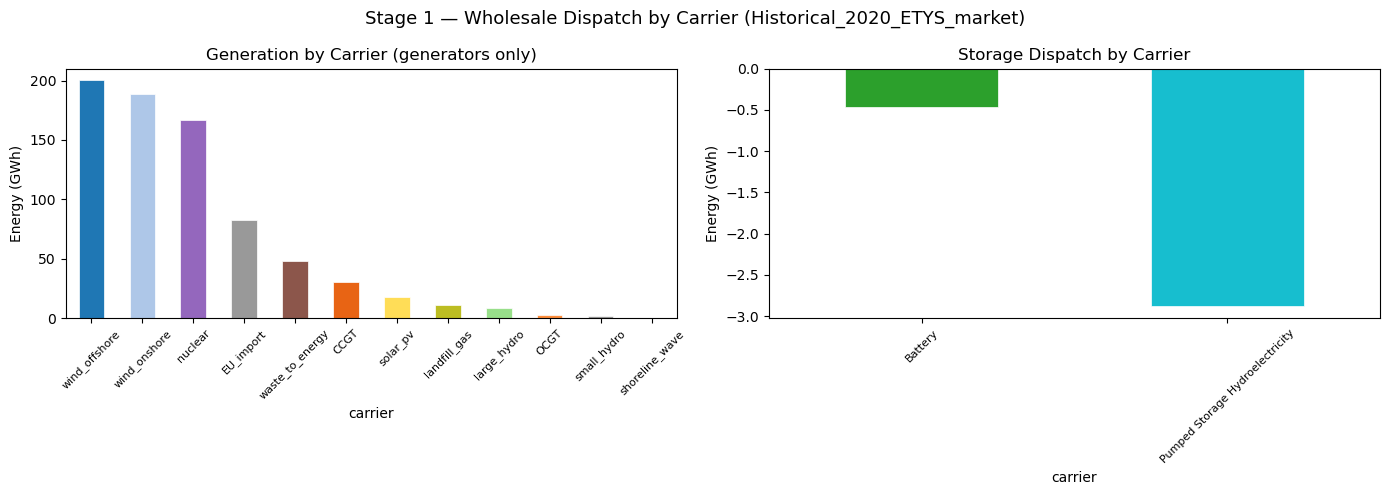

In [3]:
import pypsa

def dispatch_by_carrier(dispatch_df, network_path):
    """Sum generator dispatch (MWh) by carrier using the network for carrier lookup."""
    try:
        n = pypsa.Network(network_path)
        carriers = n.generators['carrier'].rename_axis('name')
        total = dispatch_df.sum().rename('MWh').to_frame()
        total['carrier'] = carriers.reindex(total.index)
        return total.groupby('carrier')['MWh'].sum()
    except Exception:
        return dispatch_df.sum().sum()

def storage_by_carrier(storage_df, network_path):
    """Sum storage dispatch (MWh) by carrier."""
    try:
        n = pypsa.Network(network_path)
        carriers = n.storage_units['carrier'].rename_axis('name')
        total = storage_df.sum().rename('MWh').to_frame()
        total['carrier'] = carriers.reindex(total.index)
        return total.groupby('carrier')['MWh'].sum()
    except Exception:
        return storage_df.sum().sum()

gen_by_c = dispatch_by_carrier(gen, PATHS['wholesale_network'])
su_by_c  = storage_by_carrier(su,  PATHS['wholesale_network'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Stage 1 — Wholesale Dispatch by Carrier ({SCENARIO})', fontsize=13)

# Generator dispatch bar chart
ax = axes[0]
if isinstance(gen_by_c, pd.Series):
    plot = gen_by_c[(gen_by_c.abs() > 100) & (gen_by_c.index != 'load_shedding')]
    plot = plot.sort_values(ascending=False)
    plot.div(1000).plot.bar(ax=ax,
        color=[COLORS.get(c, '#999') for c in plot.index],
        edgecolor='white', linewidth=0.5)
    ax.set_title('Generation by Carrier (generators only)')
    ax.set_ylabel('Energy (GWh)')
    ax.tick_params(axis='x', labelrotation=45)
    ax.xaxis.set_tick_params(labelsize=8)

# Storage dispatch bar chart
ax2 = axes[1]
if isinstance(su_by_c, pd.Series):
    su_plot = su_by_c[su_by_c.abs() > 10].sort_values(ascending=False)
    su_plot.div(1000).plot.bar(ax=ax2,
        color=[COLORS.get(c, '#999') for c in su_plot.index],
        edgecolor='white', linewidth=0.5)
    ax2.set_title('Storage Dispatch by Carrier')
    ax2.set_ylabel('Energy (GWh)')
    ax2.tick_params(axis='x', labelrotation=45)
    ax2.xaxis.set_tick_params(labelsize=8)

plt.tight_layout()
plt.show()

---

## Stage 1: Wholesale Clearing Price

### Interpreting the price

In a copperplate solve, **every demand bus has the same marginal price** (the dual variable of the nodal power balance constraint). The price equals the marginal cost of the most expensive generator dispatched — i.e., the generator on the margin.

The **price spread** across buses is a diagnostic: in a true copperplate solve it should be essentially zero (≤ £0.01/MWh). A non-zero spread indicates numerical solver tolerance effects — normal for large networks.

> **Note on the 2020 historical scenario:** The wholesale price reported here (~£65–66/MWh) reflects the CCGT marginal cost for a typical January day, which aligns well with actual Day-Ahead prices in early 2020 (~£55–70/MWh). The model does not calibrate against actual outturn — this is a fundamental model result.

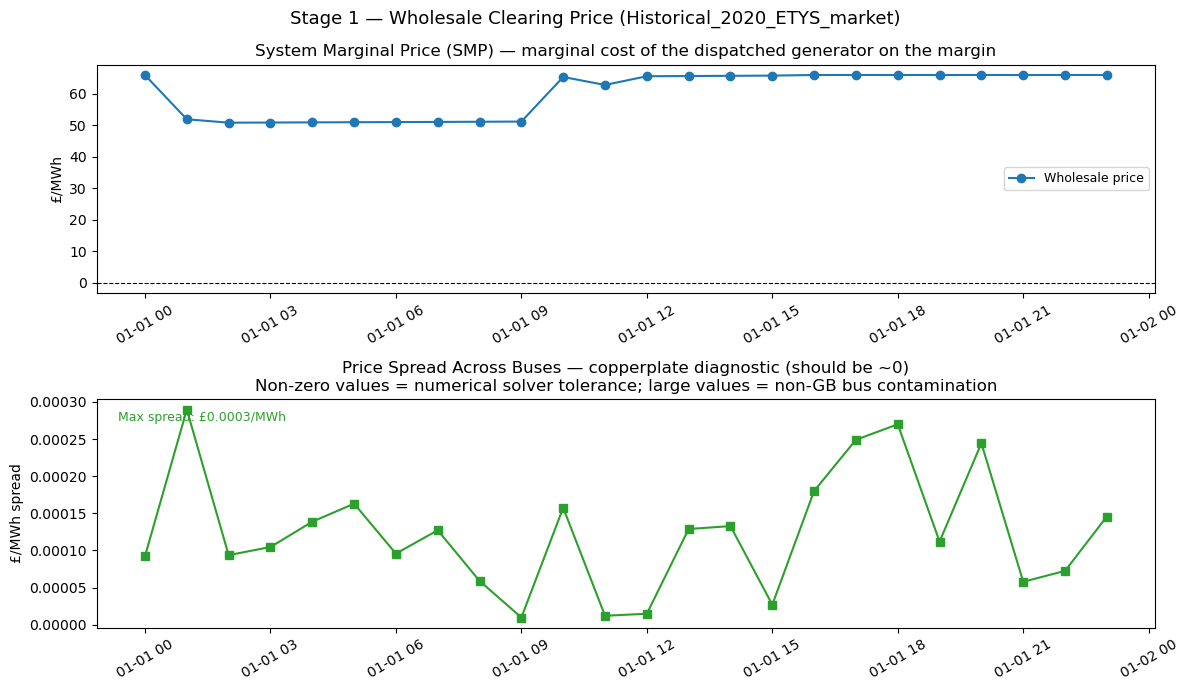

Wholesale price  mean : £60.19/MWh
Wholesale price  min  : £50.84/MWh
Wholesale price  max  : £65.97/MWh
Copperplate spread max: £0.0003/MWh


In [4]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7))
fig.suptitle(f'Stage 1 — Wholesale Clearing Price ({SCENARIO})', fontsize=13)

# Price time series
ax = axes[0]
ax.plot(wp.index, wp['wholesale_price'], marker='o', color='#1f77b4', label='Wholesale price')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('System Marginal Price (SMP) — marginal cost of the dispatched generator on the margin')
ax.set_ylabel('£/MWh')
ax.legend(fontsize=9)
ax.tick_params(axis='x', labelrotation=30)

# Price spread (copperplate diagnostic)
ax2 = axes[1]
max_spread = wp['price_spread'].max()
spread_color = '#d62728' if max_spread > 10 else '#2ca02c'
ax2.plot(wp.index, wp['price_spread'], marker='s', color=spread_color)
ax2.set_title(
    'Price Spread Across Buses — copperplate diagnostic (should be ~0)\n'
    'Non-zero values = numerical solver tolerance; large values = non-GB bus contamination'
)
ax2.set_ylabel('£/MWh spread')
ax2.tick_params(axis='x', labelrotation=30)
ax2.text(0.02, 0.95, f'Max spread: £{max_spread:,.4f}/MWh',
         transform=ax2.transAxes, va='top', color=spread_color, fontsize=9)

plt.tight_layout()
plt.show()

print(f'Wholesale price  mean : £{wp["wholesale_price"].mean():.2f}/MWh')
print(f'Wholesale price  min  : £{wp["wholesale_price"].min():.2f}/MWh')
print(f'Wholesale price  max  : £{wp["wholesale_price"].max():.2f}/MWh')
print(f'Copperplate spread max: £{max_spread:,.4f}/MWh')

---

## Stage 2: Balancing Mechanism — Redispatch Volumes

### What happens in Stage 2?

The BM solve restores full network physics (real `s_nom` on every line and transformer) and anchors each generator to its wholesale position using additional linopy constraints:

$$p_{g,t} = p^{\text{wholesale}}_{g,t} + \text{increase}_{g,t} - \text{decrease}_{g,t}$$

The new minimum-cost objective is:

$$\min \sum_{g,t} \left( \text{offer}_g \cdot \text{increase}_{g,t} + \text{bid}_g \cdot \text{decrease}_{g,t} \right)$$

The BM clears congestion by paying generators *north of a constraint* to reduce output (accept their bid) and generators *south of a constraint* to increase output (accept their offer).

### What do the redispatch volumes tell us?

- **Large increases in a region** → that region is import-constrained; NESO pays local generators extra to run up
- **Large decreases in a region** → that region is export-constrained; NESO pays generators to reduce
- **Symmetric increase = decrease** → the BM is balancing a constraint between two regions

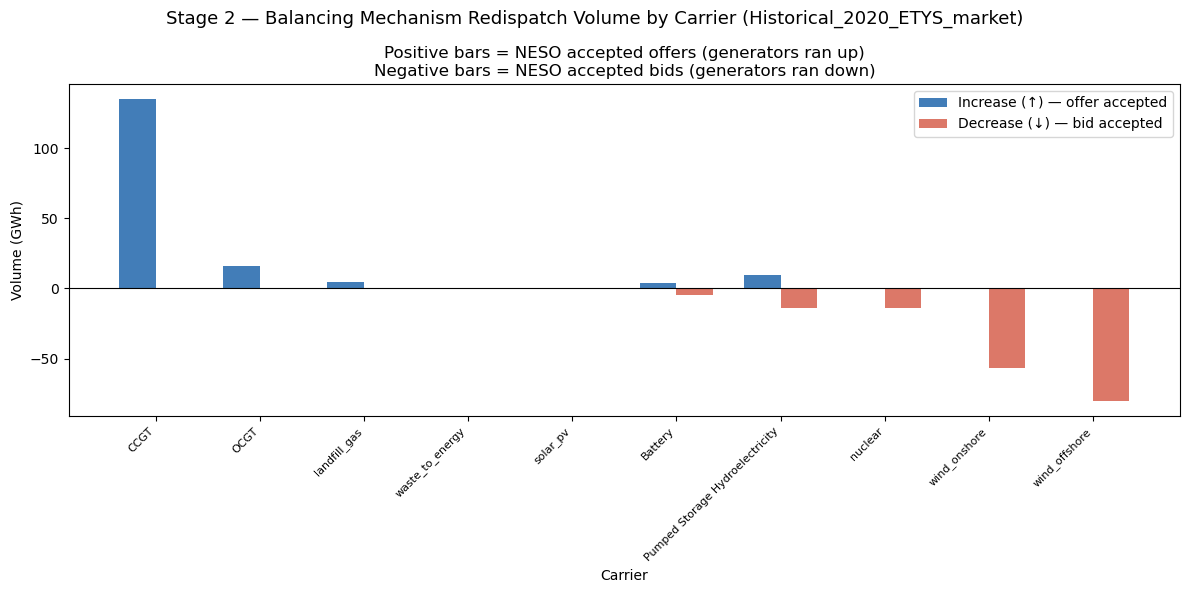

In [5]:
fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle(f'Stage 2 — Balancing Mechanism Redispatch Volume by Carrier ({SCENARIO})', fontsize=13)

if 'carrier' in rd.columns:
    by_c = rd.groupby('carrier')[['increase_MWh', 'decrease_MWh']].sum()
    by_c = by_c[by_c.sum(axis=1) > 1].copy()
    by_c['net'] = by_c['increase_MWh'] - by_c['decrease_MWh']
    by_c = by_c.sort_values('net', ascending=False)

    x = np.arange(len(by_c))
    w = 0.35
    ax.bar(x - w/2, by_c['increase_MWh'] / 1000, w, label='Increase (↑) — offer accepted',
           color='#2166ac', alpha=0.85)
    ax.bar(x + w/2, -by_c['decrease_MWh'] / 1000, w, label='Decrease (↓) — bid accepted',
           color='#d6604d', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(by_c.index, rotation=45, ha='right', fontsize=8)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_ylabel('Volume (GWh)')
    ax.set_xlabel('Carrier')
    ax.legend()
    ax.set_title(
        'Positive bars = NESO accepted offers (generators ran up)\n'
        'Negative bars = NESO accepted bids (generators ran down)'
    )
else:
    ax.text(0.5, 0.5, 'carrier column not found in redispatch CSV',
            ha='center', va='center', transform=ax.transAxes)

plt.tight_layout()
plt.show()

---

## Stage 2: BM Constraint Costs by Carrier

### BM cost structure

The BM cost is the **system cost of resolving network constraints**. It is paid by consumers via the Balancing Services Use of System (BSUoS) charge in the real market.

$$\text{BM cost} = \sum_g \bigl( \text{offer}_g \cdot \text{increase}_g + \text{bid}_g \cdot \text{decrease}_g \bigr)$$

Key observations to look for:
- **Load shedding** appearing in BM costs signals a genuine capacity shortage *after* network constraints are imposed (a bus is isolated or constrained off)
- **High CCGT costs** typically mean gas plant near congested interconnections is being re-dispatched to manage flows
- **High renewables decrease** costs suggest excess renewable generation constrained behind a bottleneck

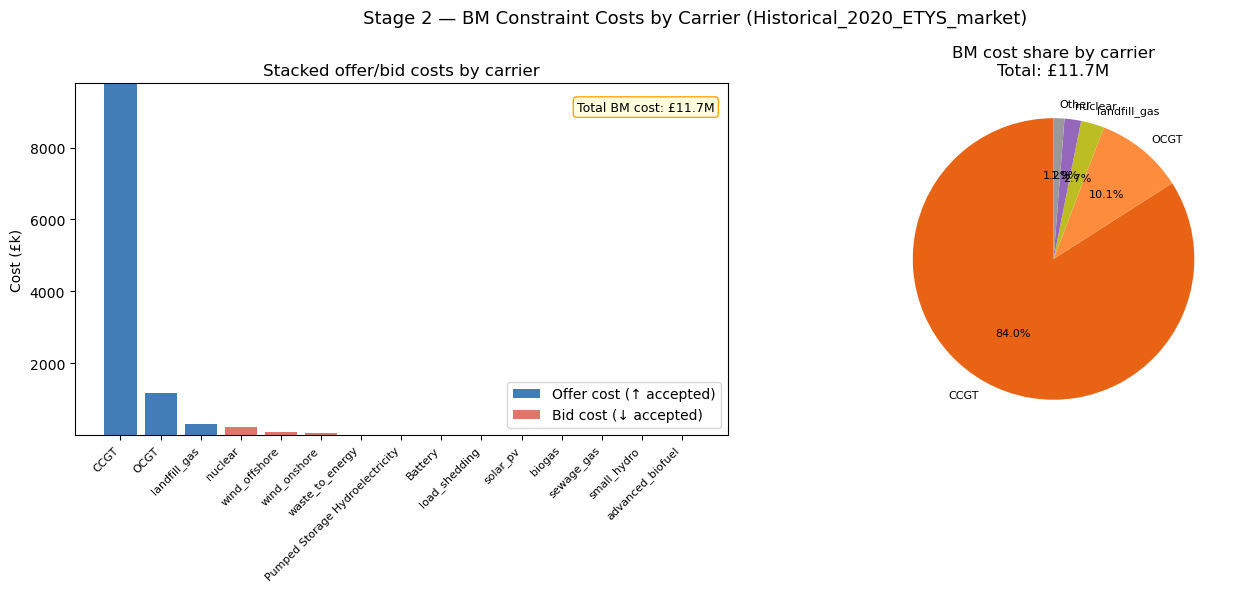

In [6]:
carrier_col = cc.columns[0]
cc_plot = cc[cc[carrier_col] != 'TOTAL'].copy()
cc_plot = cc_plot[cc_plot['net_cost'].abs() > 1].copy()
cc_plot = cc_plot.sort_values('net_cost', ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f'Stage 2 — BM Constraint Costs by Carrier ({SCENARIO})', fontsize=13)

# Stacked bar: offer cost + bid cost
ax = axes[0]
x = np.arange(len(cc_plot))
ax.bar(x, cc_plot['offer_cost'] / 1000, label='Offer cost (↑ accepted)', color='#2166ac', alpha=0.85)
ax.bar(x, cc_plot['bid_cost'] / 1000, label='Bid cost (↓ accepted)', color='#d6604d', alpha=0.85,
       bottom=cc_plot['offer_cost'] / 1000)
ax.set_xticks(x)
ax.set_xticklabels(cc_plot[carrier_col], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Cost (£k)')
ax.set_title('Stacked offer/bid costs by carrier')
ax.legend()
total_cost = cc_plot['net_cost'].sum()
ax.text(0.98, 0.95, f'Total BM cost: {fmt_gbp(total_cost)}',
        transform=ax.transAxes, ha='right', va='top', fontsize=9,
        bbox=dict(boxstyle='round', fc='lightyellow', ec='orange'))

# Pie: share of total BM cost
ax2 = axes[1]
threshold = total_cost * 0.01
main = cc_plot[cc_plot['net_cost'] >= threshold].copy()
other_val = cc_plot[cc_plot['net_cost'] < threshold]['net_cost'].sum()
if other_val > 1:
    main = pd.concat([main, pd.DataFrame([{carrier_col: 'Other', 'net_cost': other_val}])],
                     ignore_index=True)
ax2.pie(main['net_cost'], labels=main[carrier_col],
        colors=[COLORS.get(c, '#999') for c in main[carrier_col]],
        autopct='%1.1f%%', startangle=90,
        explode=[0.05 if c == 'load_shedding' else 0 for c in main[carrier_col]],
        textprops={'fontsize': 8})
ax2.set_title(f'BM cost share by carrier\nTotal: {fmt_gbp(total_cost)}')

plt.tight_layout()
plt.show()

---

## Stage 2: Top BM Assets

This table identifies the individual generators with the largest BM activity — both those **increased** (running up to relieve import constraints) and those **decreased** (running down to relieve export constraints). In the real BM, these would be the generators receiving the most BM instruction notices (BOAs/SOs).

In [7]:
comp_col = rd.columns[0]

print(f'=== {SCENARIO} — Top 15 by Increase (offer accepted) ===')
show = [c for c in [comp_col, 'carrier', 'increase_MWh', 'offer_cost'] if c in rd.columns]
df_up = rd.nlargest(15, 'increase_MWh')[show].copy()
df_up['increase_MWh'] = df_up['increase_MWh'].map('{:,.0f}'.format)
df_up['offer_cost']   = df_up['offer_cost'].map('£{:,.0f}'.format)
display(df_up.reset_index(drop=True))

print()
print(f'=== {SCENARIO} — Top 15 by Decrease (bid accepted) ===')
show2 = [c for c in [comp_col, 'carrier', 'decrease_MWh', 'bid_cost'] if c in rd.columns]
df_dn = rd.nlargest(15, 'decrease_MWh')[show2].copy()
df_dn['decrease_MWh'] = df_dn['decrease_MWh'].map('{:,.0f}'.format)
df_dn['bid_cost']     = df_dn['bid_cost'].map('£{:,.0f}'.format)
display(df_dn.reset_index(drop=True))

=== Historical_2020_ETYS_market — Top 15 by Increase (offer accepted) ===


,component,carrier,increase_MWh,offer_cost
0,South Humber Bank,CCGT,"31,657","£2,297,215"
1,Saltend*,CCGT,"27,419","£1,989,643"
2,West Burton CCGT,CCGT,"22,769","£1,652,225"
3,Keadby,CCGT,"16,343","£1,185,950"
4,Staythorpe C,CCGT,"15,813","£1,147,468"
5,Killingholme,OCGT,"13,586","£985,888"
6,Spalding,CCGT,"12,699","£921,479"
7,Dinorwig_0,Pumped Storage Hydroelectricity,"7,343",£0
8,VPI Immingham*,CCGT,"3,127","£226,911"
9,Sutton Bridge,CCGT,"2,916","£211,581"



=== Historical_2020_ETYS_market — Top 15 by Decrease (bid accepted) ===


,component,carrier,decrease_MWh,bid_cost
0,Hunterston B,nuclear,"13,663","£221,068"
1,Walney_3,wind_offshore,"11,016","£10,183"
2,London_Array Phase_1,wind_offshore,"9,297","£8,593"
3,Greater_Gabbard_Wind_Farm,wind_offshore,"7,534","£6,964"
4,Dudgeon_East,wind_offshore,"6,609","£6,109"
5,Dinorwig_0,Pumped Storage Hydroelectricity,"5,695","£2,847"
6,Galloper_Wind_Farm,wind_offshore,"5,021","£4,642"
7,Race_Bank_Phase_1,wind_offshore,"5,011","£4,632"
8,Race_Bank_Phase_2,wind_offshore,"4,894","£4,524"
9,Kilgallioch_wind_farm,wind_onshore,"4,661","£4,308"


---

## Stage 2: Network Congestion

### What is congestion in this context?

A line or transformer is **congested** when the BM solve tries to push more power through it than its thermal rating allows. The BM congestion analysis identifies components loaded above 95% of their `s_nom` rating.

In the real network, persistent congestion at specific boundaries (e.g. the B6 Scotland–England boundary, or radial 132kV feeders) drives significant BM costs. The ETYS network model here has 2,000+ buses and 3,700+ branches, so congestion can occur at realistic constraint locations.

> **Tip:** If there is no congestion after Stage 2, the wholesale dispatch was already physically feasible — the BM make no changes and total BM cost ≈ 0.

Historical_2020_ETYS_market: 43 congested components (>95% loading threshold)


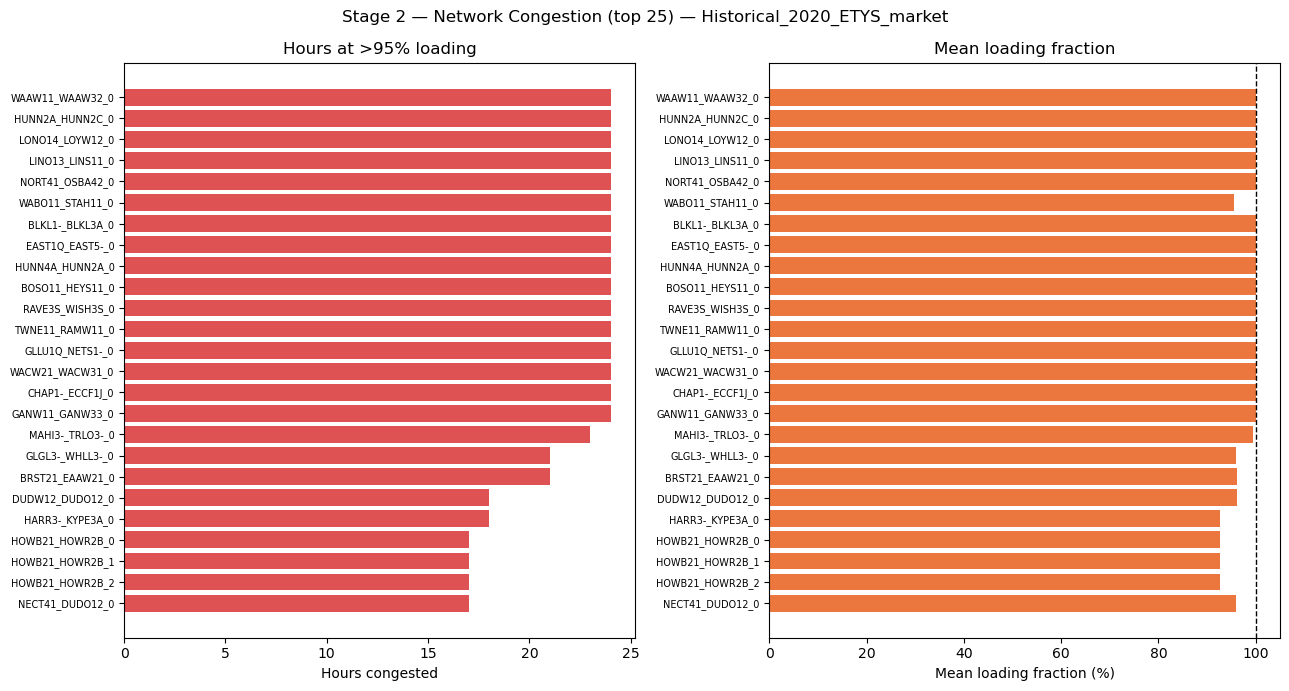

In [8]:
print(f'{SCENARIO}: {len(cg)} congested components (>95% loading threshold)')

if len(cg) == 0:
    print('  No congestion — the wholesale dispatch was already network-feasible.')
    print('  BM cost arises only from bid/offer markup rather than constraint management.')
else:
    sort_col = 'hours_congested' if 'hours_congested' in cg.columns else cg.columns[0]
    top_cg = cg.sort_values(sort_col, ascending=False).head(25).reset_index(drop=True)
    comp_label = top_cg.columns[0]
    y_labels = top_cg[comp_label].astype(str)

    n_ax = 2 if 'mean_loading_fraction' in top_cg.columns else 1
    fig, axes = plt.subplots(1, n_ax, figsize=(13, max(4, len(top_cg) * 0.28)))
    if n_ax == 1:
        axes = [axes]
    fig.suptitle(f'Stage 2 — Network Congestion (top 25) — {SCENARIO}', fontsize=12)

    axes[0].barh(range(len(top_cg)), top_cg['hours_congested'], color='#d62728', alpha=0.8)
    axes[0].set_yticks(range(len(top_cg)))
    axes[0].set_yticklabels(y_labels, fontsize=7)
    axes[0].set_xlabel('Hours congested')
    axes[0].set_title('Hours at >95% loading')
    axes[0].invert_yaxis()

    if n_ax == 2:
        axes[1].barh(range(len(top_cg)), top_cg['mean_loading_fraction'] * 100,
                     color='#e6550d', alpha=0.8)
        axes[1].axvline(100, color='black', linewidth=1, linestyle='--')
        axes[1].set_yticks(range(len(top_cg)))
        axes[1].set_yticklabels(y_labels, fontsize=7)
        axes[1].set_xlabel('Mean loading fraction (%)')
        axes[1].set_title('Mean loading fraction')
        axes[1].invert_yaxis()

    plt.tight_layout()
    plt.show()

---

## Wholesale vs BM Nodal Prices

### What the price comparison shows

| Price | Definition |
|-------|------------|
| Wholesale price | Uniform SMP from Stage 1 copperplate solve (£/MWh, same everywhere) |
| BM mean nodal price | Average of per-bus dual variables in Stage 2 (varies by location) |
| BM nodal spread | Max − Min across GB demand buses in Stage 2 |

The **nodal spread** in Stage 2 is the key measure of **locational marginal pricing (LMP)** — how much the network constraints are worth in monetary terms. A spread of, say, £30/MWh across Scotland and south England means:

> Generators *south* of a bottleneck would be paid £30/MWh more than generators *north* if the GB operated a nodal pricing market (as in the US PJM or MISO markets). The BM approximates this through cash-out.

GB does **not** operate nodal pricing — the wholesale price is uniform and the BM handles constraint costs as a post-settlement adjustment. This model simulates the equivalent economic outcome.

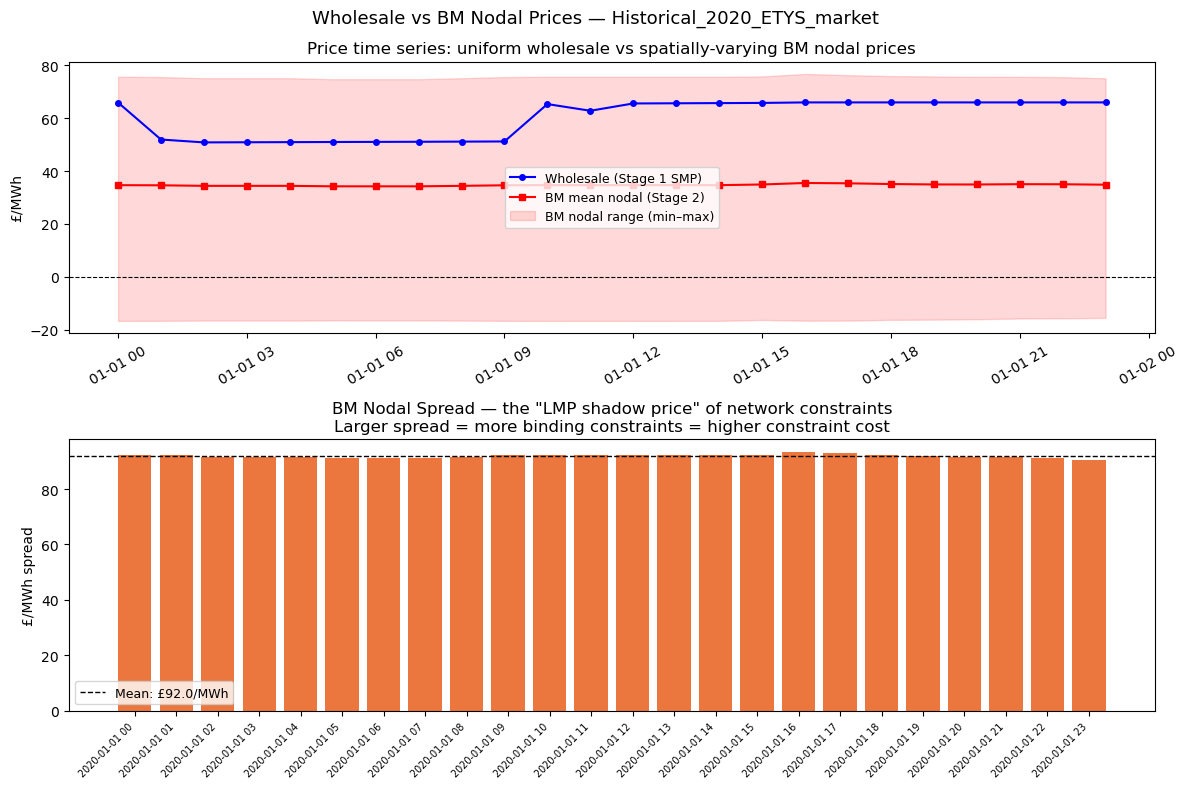

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
fig.suptitle(f'Wholesale vs BM Nodal Prices — {SCENARIO}', fontsize=13)

# Price time series comparison
ax = axes[0]
if 'wholesale_price' in pc.columns:
    ax.plot(pc.index, pc['wholesale_price'], 'b-o', ms=4, label='Wholesale (Stage 1 SMP)', zorder=3)
if 'mean_nodal_price' in pc.columns:
    ax.plot(pc.index, pc['mean_nodal_price'], 'r-s', ms=4, label='BM mean nodal (Stage 2)', zorder=3)
if 'min_nodal_price' in pc.columns and 'max_nodal_price' in pc.columns:
    ax.fill_between(pc.index, pc['min_nodal_price'], pc['max_nodal_price'],
                    alpha=0.15, color='red', label='BM nodal range (min–max)')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title(
    'Price time series: uniform wholesale vs spatially-varying BM nodal prices'
)
ax.set_ylabel('£/MWh')
ax.legend(fontsize=9)
ax.tick_params(axis='x', labelrotation=30)

# BM nodal spread
ax2 = axes[1]
if 'nodal_spread' in pc.columns:
    ax2.bar(range(len(pc)), pc['nodal_spread'], color='#e6550d', alpha=0.8)
    mean_spread = pc['nodal_spread'].mean()
    ax2.axhline(mean_spread, color='black', linestyle='--', linewidth=1, label=f'Mean: £{mean_spread:.1f}/MWh')
    ax2.set_title(
        'BM Nodal Spread — the "LMP shadow price" of network constraints\n'
        'Larger spread = more binding constraints = higher constraint cost'
    )
    ax2.set_ylabel('£/MWh spread')
    ax2.set_xticks(range(len(pc)))
    ax2.set_xticklabels([str(t)[:13] for t in pc.index], rotation=45, ha='right', fontsize=7)
    ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

---

## Summary Statistics

The table below summarises the full two-stage dispatch result for the selected scenario and solve period.

In [10]:
total_bm_arr = cc[cc[cc.columns[0]] == 'TOTAL']['net_cost'].values
total_bm = total_bm_arr[0] if len(total_bm_arr) else rd['net_cost'].sum()

ls_arr = cc[cc[cc.columns[0]] == 'load_shedding']['net_cost'].values
ls_cost = ls_arr[0] if len(ls_arr) else 0

summary = pd.DataFrame([{
    'Scenario':                             SCENARIO,
    'Timesteps':                            len(wp),
    'Stage 1 — wholesale assets':           len(gen.columns),
    'Stage 2 — BM assets total':            len(rd),
    'Stage 2 — assets increased (↑)':       int((rd['increase_MWh'] > 0.1).sum()),
    'Stage 2 — assets decreased (↓)':       int((rd['decrease_MWh'] > 0.1).sum()),
    'Total generation (GWh)':               f"{gen.sum().sum()/1000:.1f}",
    'Wholesale price — mean (£/MWh)':       f"{wp['wholesale_price'].mean():.2f}",
    'Wholesale price — min (£/MWh)':        f"{wp['wholesale_price'].min():.2f}",
    'Wholesale price — max (£/MWh)':        f"{wp['wholesale_price'].max():.2f}",
    'BM increase volume (GWh)':             f"{rd['increase_MWh'].sum()/1000:.2f}",
    'BM decrease volume (GWh)':             f"{rd['decrease_MWh'].sum()/1000:.2f}",
    'Total BM constraint cost':             fmt_gbp(total_bm),
    'Load shedding BM cost':                fmt_gbp(ls_cost),
    'Congested components (>95%)':          len(cg),
    'BM mean nodal spread (£/MWh)':         (
        f"{pc['nodal_spread'].mean():.1f}" if 'nodal_spread' in pc.columns else 'N/A'
    ),
}]).set_index('Scenario').T

display(summary)

Scenario,Historical_2020_ETYS_market
Timesteps,24
Stage 1 — wholesale assets,4704
Stage 2 — BM assets total,4778
Stage 2 — assets increased (↑),328
Stage 2 — assets decreased (↓),393
Total generation (GWh),759.6
Wholesale price — mean (£/MWh),60.19
Wholesale price — min (£/MWh),50.84
Wholesale price — max (£/MWh),65.97
BM increase volume (GWh),169.40


---

## Further Reading & Configuration

### How to run the two-stage market dispatch

Any scenario can be run with the market dispatch enabled by setting `market.enabled: true` in `config/scenarios.yaml` or `config/defaults.yaml`:

```yaml
My_Scenario:
  modelled_year: 2030
  network_model: ETYS
  market:
    enabled: true
    wholesale:
      transmission_relaxation: 1.0e6   # copperplate MVA rating
    balancing:
      bid_offer_source: derived
      default_offer_markup: 0.10
      default_bid_discount: 0.10
      carrier_overrides:
        nuclear:        {offer_markup: 0.50, bid_discount: 0.05}
        wind_onshore:   {offer_markup: 0.00, bid_discount: 0.05}
        battery:        {offer_markup: 0.15, bid_discount: 0.15}
      fix_interconnectors: true
```

Then run:
```bash
conda activate pypsa-gb
snakemake -j 4 --latency-wait 60
```

### Key source files

| File | Role |
|------|------|
| `scripts/market/solve_wholesale.py` | Stage 1 implementation |
| `scripts/market/solve_balancing.py` | Stage 2 implementation |
| `scripts/market/market_utils.py` | Bid/offer pricing, redispatch computation, congestion analysis |
| `scripts/market/analyze_market.py` | Dashboard and summary generation |
| `rules/market.smk` | Snakemake rules wiring the stages together |
| `config/defaults.yaml` | Default market configuration |

### Known limitations

1. **Bid/offer prices are derived** from marginal costs — real BM participants use strategic pricing that may differ significantly
2. **Unit commitment** is not modelled in LP mode — start-up and no-load costs are excluded
3. **Intra-day redispatch** is not sequential — the BM is solved as a single batch LP over all timesteps
4. **Interconnector flows** in historical scenarios are fixed to ESPENI observed values — they do not re-optimise in Stage 2